In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import re
import sys
import json
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Optional, Tuple, Any
import pandas as pd
from joblib import Parallel, delayed
import numpy as np
from IPython.display import Image

In [2]:
from pathlib import Path
import itertools

In [3]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('.') 

In [4]:
from utils import collect_records, consolidate_recognition_results, plot_fr_dist_by_train_domain, add_normalized_wasserstein, plot_pareto_2d_stacked
from utils import aggregate_for_plots, join_fr_dist_stats_wm_metrics_by_condition_pair, aggregate_for_plots, plot_spider, plot_pareto_2d, compute_fr_distributions_stats

In [5]:
excel_path = r"C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval\evaluation\results\consolidated_results_wm.xlsx"
df_wm = pd.read_excel(excel_path)
df_wm

,algorithm,experiment_name,inference_dataset,timestamp,json_path,model_name,training_dataset,bpp,accuracy,accuracy_std,accuracy_offline,accuracy_offline_std,psnr,psnr_std,psnr_offline,psnr_offline_std,ssim,ssim_std,ssim_offline,ssim_offline_std
0,stegaformer,15_2_255_w16_learn_im,CFD,2025-10-21T08:13:37.472928,C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval...,stegaformer,celeba_hq,8,0.937299,0.022923,0.404749,0.008359,40.312687,0.615535,39.455111,0.621893,0.981888,0.001946,0.979871,0.002419
1,stegaformer,15_2_255_w16_learn_im,facelab_london,2025-10-21T06:55:38.942469,C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval...,stegaformer,celeba_hq,8,0.999031,0.000503,0.408073,0.003708,44.230556,0.213142,43.497968,0.392890,0.980045,0.000768,0.977755,0.001250
2,stegaformer,15_2_255_w16_learn_im,LFW,2025-10-21T07:08:36.765220,C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval...,stegaformer,celeba_hq,8,0.969427,0.009911,0.391804,0.021553,42.485462,0.828977,42.453405,1.363503,0.969923,0.010131,0.971916,0.014172
3,stegaformer,15_2_255_w16_learn_im,ONOT,2025-10-21T08:00:47.887483,C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval...,stegaformer,celeba_hq,8,0.990195,0.004346,0.425640,0.010925,41.223110,0.814447,40.876709,1.358807,0.982537,0.001484,0.980623,0.002637
4,stegaformer,15_2_255_w16_learn_im,ONOT_set1,2025-10-25T15:40:28.243583,C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval...,stegaformer,celeba_hq,8,0.991587,0.003843,0.424192,0.009277,41.387985,0.738361,40.940191,1.233124,0.982722,0.001260,0.980813,0.002755
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,stegformer,3_6_clamp_StegFormer-B_baseline,facelab_london,2026-04-07T12:26:24.882226,C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval...,stegformer,coco,6,0.997723,0.000194,0.957111,0.000560,34.730068,0.624793,34.752552,0.872257,0.930335,0.003150,0.928292,0.004162
92,stegformer,3_6_clamp_StegFormer-B_baseline,LFW,2026-04-12T22:48:22.400806,C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval...,stegformer,coco,6,0.995453,0.000779,0.953726,0.002000,32.548660,1.503574,32.726974,1.991156,0.895993,0.030599,0.898616,0.038981
93,stegformer,3_6_clamp_StegFormer-B_baseline,ONOT,2026-04-07T13:02:56.697760,C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval...,stegformer,coco,6,0.995557,0.000717,0.954461,0.001651,31.044853,1.075708,31.132278,1.517244,0.912009,0.008750,0.911297,0.011852
94,stegformer,3_6_clamp_StegFormer-B_baseline,ONOT_set1,2026-04-14T06:34:56.345885,C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval...,stegformer,coco,6,0.995633,0.000638,0.954615,0.001548,31.215025,0.940091,31.248352,1.323062,0.912843,0.007819,0.912101,0.010781


In [6]:
df_wm.keys()

Index(['algorithm', 'experiment_name', 'inference_dataset', 'timestamp',
       'json_path', 'model_name', 'training_dataset', 'bpp', 'accuracy',
       'accuracy_std', 'accuracy_offline', 'accuracy_offline_std', 'psnr',
       'psnr_std', 'psnr_offline', 'psnr_offline_std', 'ssim', 'ssim_std',
       'ssim_offline', 'ssim_offline_std'],
      dtype='object')

In [7]:
df_wm_online = df_wm[['algorithm','training_dataset','inference_dataset','bpp',
                        'accuracy','psnr','ssim']].copy()
df_wm_online.columns = ['watermark','train_dataset','test_dataset','bpp','accuracy','psnr','ssim']
df_wm_online['mode'] = 'online'

df_wm_offline = df_wm[['algorithm','training_dataset','inference_dataset','bpp',
                         'accuracy_offline','psnr_offline','ssim_offline']].copy()
df_wm_offline.columns = ['watermark','train_dataset','test_dataset','bpp','accuracy','psnr','ssim']
df_wm_offline['mode'] = 'offline'

df_wm_long = pd.concat([df_wm_online, df_wm_offline], ignore_index=True)

In [8]:
df_wm_long

,watermark,train_dataset,test_dataset,bpp,accuracy,psnr,ssim,mode
0,stegaformer,celeba_hq,CFD,8,0.937299,40.312687,0.981888,online
1,stegaformer,celeba_hq,facelab_london,8,0.999031,44.230556,0.980045,online
2,stegaformer,celeba_hq,LFW,8,0.969427,42.485462,0.969923,online
3,stegaformer,celeba_hq,ONOT,8,0.990195,41.223110,0.982537,online
4,stegaformer,celeba_hq,ONOT_set1,8,0.991587,41.387985,0.982722,online
...,...,...,...,...,...,...,...,...
187,stegformer,coco,facelab_london,6,0.957111,34.752552,0.928292,offline
188,stegformer,coco,LFW,6,0.953726,32.726974,0.898616,offline
189,stegformer,coco,ONOT,6,0.954461,31.132278,0.911297,offline
190,stegformer,coco,ONOT_set1,6,0.954615,31.248352,0.912101,offline


In [9]:
root = r'C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval\experiments\output\recognition'
root = Path(root)

In [10]:
fr_results = consolidate_recognition_results(root)

Encontrados 384 archivos JSON de resultados
DataFrame creado con 384 registros y 44 columnas


In [11]:
fr_results

,watermarking_algorithm,experiment_name,bpp,train_dataset,test_dataset,recognizer,modality,face_detection,json_file,full_path,...,avg_var_dist_cosine_impostor_due_watermark,avg_var_dist_cosine_impostor_due_watermark_both,std_raw_dist_cosine_genuine_raw_vs_watermark,std_raw_dist_cosine_genuine_raw_vs_watermark_template,std_raw_dist_cosine_impostor_raw_vs_watermark,std_raw_dist_cosine_impostor_raw_vs_watermark_template,std_var_dist_cosine_genuine_due_watermark,std_var_dist_cosine_genuine_due_watermark_both,std_var_dist_cosine_impostor_due_watermark,std_var_dist_cosine_impostor_due_watermark_both
0,stegaformer,1_1_255_w16_learn_im,1,celeba_hq,SCface,arcface,offline,mtcnn,results_summary_mtcnn.json,C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval...,...,0.000,0.004,0.000,0.000,0.087,0.082,0.144,0.171,0.130,0.160
1,stegaformer,1_1_255_w16_learn_im,1,celeba_hq,ONOT_set1,arcface,offline,mtcnn,results_summary_mtcnn.json,C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval...,...,-0.003,-0.005,0.000,0.000,0.106,0.112,0.071,0.110,0.072,0.112
2,stegaformer,1_1_255_w16_learn_im,1,celeba_hq,ONOT,arcface,offline,mtcnn,results_summary_mtcnn.json,C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval...,...,-0.007,-0.010,0.000,0.000,0.102,0.112,0.074,0.111,0.073,0.109
3,stegaformer,1_1_255_w16_learn_im,1,celeba_hq,LFW,arcface,offline,mtcnn,results_summary_mtcnn.json,C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval...,...,0.003,0.005,0.000,0.000,0.071,0.071,0.136,0.188,0.148,0.210
4,stegaformer,1_1_255_w16_learn_im,1,celeba_hq,facelab_london,arcface,offline,mtcnn,results_summary_mtcnn.json,C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval...,...,-0.001,-0.004,0.000,0.000,0.080,0.079,0.047,0.073,0.100,0.147
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,stegformer,2_8_clamp_StegFormer-B_baseline,8,coco,ONOT_set1,facenet,online,mtcnn,results_summary_online_mtcnn.json,C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval...,...,0.014,0.010,0.000,0.001,0.196,0.200,0.318,0.545,0.441,0.731
380,stegformer,2_8_clamp_StegFormer-B_baseline,8,coco,ONOT,facenet,online,mtcnn,results_summary_online_mtcnn.json,C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval...,...,-0.006,-0.009,0.000,0.001,0.189,0.198,0.372,0.555,0.448,0.752
381,stegformer,2_8_clamp_StegFormer-B_baseline,8,coco,LFW,facenet,online,mtcnn,results_summary_online_mtcnn.json,C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval...,...,-0.024,-0.053,0.000,0.000,0.155,0.154,0.355,0.478,0.440,0.627
382,stegformer,2_8_clamp_StegFormer-B_baseline,8,coco,facelab_london,facenet,online,mtcnn,results_summary_online_mtcnn.json,C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval...,...,0.058,0.165,0.001,0.000,0.158,0.155,0.224,0.287,0.591,0.843


In [12]:
fr_results.keys()

Index(['watermarking_algorithm', 'experiment_name', 'bpp', 'train_dataset',
       'test_dataset', 'recognizer', 'modality', 'face_detection', 'json_file',
       'full_path', 'AUC_baseline_cosine', 'AUC_watermarked_both_cosine',
       'AUC_watermarked_cosine', 'Actual_FAR_baseline_cosine',
       'Actual_FAR_watermarked_both_cosine', 'Actual_FAR_watermarked_cosine',
       'EER_baseline_cosine', 'EER_watermarked_both_cosine',
       'EER_watermarked_cosine', 'FAR_at_EER_baseline_cosine',
       'FAR_at_EER_watermarked_both_cosine', 'FAR_at_EER_watermarked_cosine',
       'FRR_at_EER_baseline_cosine', 'FRR_at_EER_watermarked_both_cosine',
       'FRR_at_EER_watermarked_cosine', 'TAR_at_FAR_baseline_cosine',
       'TAR_at_FAR_watermarked_both_cosine', 'TAR_at_FAR_watermarked_cosine',
       'avg_raw_dist_cosine_genuine_raw_vs_watermark',
       'avg_raw_dist_cosine_genuine_raw_vs_watermark_template',
       'avg_raw_dist_cosine_impostor_raw_vs_watermark',
       'avg_raw_dist_cosine_i

In [119]:
root = Path(r'C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval\experiments\output\recognition')

watermarks   = ['stegformer'] #'stegaformer'
recognizers  = ['arcface','facenet'] #, 'facenet'
modes        = ['offline'] #'online', 
test_datasets = ['SCface']#['facelab_london', 'CFD']#['ONOT_set1','facelab_london', 'CFD','SCface'] #['facelab_london', 'CFD'] # 'ONOT', 'ONOT_set1', , # 'SCface'
train_datasets = ['coco'] # 
metric = 'cosine'
mtcnn  = 'mtcnn'

all_records = []

for wm, rec, mode, train in itertools.product(watermarks, recognizers, modes, train_datasets):
    try:
        recs = collect_records(
            root, wm, rec, metric,
            train_filter=train,
            test_filter=set(test_datasets),
            mode=mode,
            mtcnn=mtcnn
        )
        all_records.extend(recs)
    except Exception as e:
        print(f"SKIP {wm}/{rec}/{mode}/{train}: {e}")

df_long = pd.DataFrame.from_records(all_records)
print(df_long.shape)
print(df_long[['watermark','recognizer','mode','train_dataset','test_dataset']].drop_duplicates())

(204360, 13)
         watermark recognizer     mode train_dataset test_dataset
0       stegformer    arcface  offline          coco       SCface
102180  stegformer    facenet  offline          coco       SCface


In [120]:
df_long.shape

(204360, 13)

In [121]:
df_long.head()

,watermark,recognizer,metric,train_dataset,test_dataset,bpp,condition,pair_type,distance,experiment,mtcnn,mode,path
0,stegformer,arcface,cosine,coco,SCface,1,OO,genuine,0.302196,1_1_clamp_StegFormer-B_baseline,mtcnn,offline,C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval...
1,stegformer,arcface,cosine,coco,SCface,1,OO,genuine,0.218083,1_1_clamp_StegFormer-B_baseline,mtcnn,offline,C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval...
2,stegformer,arcface,cosine,coco,SCface,1,OO,genuine,0.601689,1_1_clamp_StegFormer-B_baseline,mtcnn,offline,C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval...
3,stegformer,arcface,cosine,coco,SCface,1,OO,genuine,0.510476,1_1_clamp_StegFormer-B_baseline,mtcnn,offline,C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval...
4,stegformer,arcface,cosine,coco,SCface,1,OO,genuine,0.676226,1_1_clamp_StegFormer-B_baseline,mtcnn,offline,C:\Users\JotaR\Documents\Github\WAFIS-ICAOeval...


In [122]:
for col in ['watermark', 'recognizer', 'train_dataset', 'test_dataset', 'bpp', 'condition', 'pair_type', 'mode']:
    print(f"{col}: {sorted(df_long[col].unique())}")

watermark: ['stegformer']
recognizer: ['arcface', 'facenet']
train_dataset: ['coco']
test_dataset: ['SCface']
bpp: [np.int64(1), np.int64(3), np.int64(6), np.int64(8)]
condition: ['OO', 'OW', 'WW']
pair_type: ['genuine', 'impostor']
mode: ['offline']


In [123]:
print(df_long.groupby(['watermark','recognizer','mode','train_dataset'])['test_dataset'].nunique())

watermark   recognizer  mode     train_dataset
stegformer  arcface     offline  coco             1
            facenet     offline  coco             1
Name: test_dataset, dtype: int64


In [124]:
df_dis_stats = compute_fr_distributions_stats(df_long)

In [125]:
print(df_dis_stats.shape)

(32, 15)


In [126]:
df_dis_stats

,watermark,recognizer,train_dataset,test_dataset,bpp,mode,pair_type,condition,kl_divergence,delta_mean,wasserstein,js_divergence,cohen_d,n_oo,n_cond
0,stegformer,arcface,coco,SCface,1,offline,genuine,OW,0.000003,0.000109,0.000674,1.015640e-06,0.001156,130,130
1,stegformer,arcface,coco,SCface,1,offline,genuine,WW,0.000017,0.000191,0.000863,6.283936e-06,0.002017,130,130
2,stegformer,arcface,coco,SCface,1,offline,impostor,OW,0.000003,0.000075,0.000155,1.117458e-06,0.000984,8385,8385
3,stegformer,arcface,coco,SCface,1,offline,impostor,WW,0.000006,0.000077,0.000182,2.103823e-06,0.001008,8385,8385
4,stegformer,arcface,coco,SCface,3,offline,genuine,OW,0.000518,0.000098,0.003230,1.848732e-04,0.001040,130,130
5,stegformer,arcface,coco,SCface,3,offline,genuine,WW,0.000865,-0.001219,0.003995,3.072008e-04,-0.012913,130,130
6,stegformer,arcface,coco,SCface,3,offline,impostor,OW,0.000413,0.001588,0.001601,1.474898e-04,0.020887,8385,8385
7,stegformer,arcface,coco,SCface,3,offline,impostor,WW,0.000384,0.001127,0.001171,1.369520e-04,0.014830,8385,8385
8,stegformer,arcface,coco,SCface,6,offline,genuine,OW,0.008583,0.009736,0.010788,3.123101e-03,0.102930,130,130
9,stegformer,arcface,coco,SCface,6,offline,genuine,WW,0.003828,0.006488,0.007647,1.375558e-03,0.069119,130,130


In [127]:
df_merged = join_fr_dist_stats_wm_metrics_by_condition_pair(df_dis_stats, df_wm_long, condition='both', pair_type='genuine')
df_merged

,watermark,train_dataset,test_dataset,bpp,accuracy,psnr,ssim,mode,recognizer,condition,kl_divergence,delta_mean,wasserstein,cohen_d,js_divergence
0,stegformer,coco,SCface,1,0.952937,50.441256,0.997992,offline,arcface,OW,0.000003,0.000109,0.000674,0.001156,0.000001
1,stegformer,coco,SCface,1,0.952937,50.441256,0.997992,offline,arcface,WW,0.000017,0.000191,0.000863,0.002017,0.000006
2,stegformer,coco,SCface,1,0.952937,50.441256,0.997992,offline,facenet,OW,0.000068,-0.000637,0.001041,-0.005436,0.000024
3,stegformer,coco,SCface,1,0.952937,50.441256,0.997992,offline,facenet,WW,0.000068,-0.000469,0.001042,-0.004000,0.000024
4,stegformer,coco,SCface,8,0.385690,42.191572,0.985472,offline,arcface,OW,0.000183,0.000713,0.001906,0.007539,0.000066
5,stegformer,coco,SCface,8,0.385690,42.191572,0.985472,offline,arcface,WW,0.000239,0.000814,0.002527,0.008591,0.000087
6,stegformer,coco,SCface,8,0.385690,42.191572,0.985472,offline,facenet,OW,0.001708,-0.001803,0.002936,-0.015489,0.000701
7,stegformer,coco,SCface,8,0.385690,42.191572,0.985472,offline,facenet,WW,0.001592,-0.001371,0.002850,-0.011781,0.000652
8,stegformer,coco,SCface,3,0.953289,35.440937,0.968720,offline,arcface,OW,0.000518,0.000098,0.003230,0.001040,0.000185
9,stegformer,coco,SCface,3,0.953289,35.440937,0.968720,offline,arcface,WW,0.000865,-0.001219,0.003995,-0.012913,0.000307


In [128]:
print(df_merged['mode'].value_counts())
print(df_merged['mode'].dtype)

mode
offline    16
Name: count, dtype: int64
object


In [129]:
df_agg = aggregate_for_plots(df_merged)

In [130]:
df_agg[(df_agg.watermark=='stegformer')&
          (df_agg.bpp==6)]

,watermark,bpp,recognizer,mode,condition,accuracy,psnr,ssim,kl_divergence,wasserstein,js_divergence,acc_norm,psnr_norm,kl_inv_norm,js_inv_norm
8,stegformer,6,arcface,offline,OW,0.955302,32.533893,0.925133,0.008583,0.010788,0.003123,1.0,0.0,7.470498e-01,0.996877
9,stegformer,6,arcface,offline,WW,0.955302,32.533893,0.925133,0.003828,0.007647,0.001376,1.0,0.0,8.871966e-01,0.998624
10,stegformer,6,facenet,offline,OW,0.955302,32.533893,0.925133,0.025053,0.009351,0.006845,1.0,0.0,2.616777e-01,0.993155
11,stegformer,6,facenet,offline,WW,0.955302,32.533893,0.925133,0.033932,0.008623,0.007224,1.0,0.0,2.947067e-09,0.992776


In [131]:
# normalize wassertein
cols = ['watermark', 'bpp', 'recognizer', 'mode', 'condition', 'pair_type']
distances_range = df_long[(df_long.pair_type=='genuine') & (df_long.condition=='OO')].groupby(cols).agg(
        min_distance=('distance', 'min'),
        max_distance=('distance', 'max')).reset_index()
distances_range

,watermark,bpp,recognizer,mode,condition,pair_type,min_distance,max_distance
0,stegformer,1,arcface,offline,OO,genuine,0.218083,0.728620
1,stegformer,1,facenet,offline,OO,genuine,0.128724,0.933184
2,stegformer,3,arcface,offline,OO,genuine,0.218083,0.728620
3,stegformer,3,facenet,offline,OO,genuine,0.128724,0.933184
4,stegformer,6,arcface,offline,OO,genuine,0.218083,0.728620
5,stegformer,6,facenet,offline,OO,genuine,0.128724,0.933184
6,stegformer,8,arcface,offline,OO,genuine,0.218083,0.728620
7,stegformer,8,facenet,offline,OO,genuine,0.128724,0.933184


In [132]:
df_agg = add_normalized_wasserstein(
    df_agg,
    distances_range,
    inverse_scope="recognizer"
)

df_agg

,watermark,bpp,recognizer,mode,condition,accuracy,psnr,ssim,kl_divergence,wasserstein,js_divergence,acc_norm,psnr_norm,kl_inv_norm,js_inv_norm,min_distance,max_distance,genuine_ref_range,ws_norm,ws_inv_norm
0,stegformer,1,arcface,offline,OW,0.952937,50.441256,0.997992,0.000003,0.000674,0.000001,0.995848,1.000000,9.999171e-01,0.999999,0.218083,0.728620,0.510538,0.001320,9.375175e-01
1,stegformer,1,arcface,offline,WW,0.952937,50.441256,0.997992,0.000017,0.000863,0.000006,0.995848,1.000000,9.994860e-01,0.999994,0.218083,0.728620,0.510538,0.001690,9.200392e-01
2,stegformer,1,facenet,offline,OW,0.952937,50.441256,0.997992,0.000068,0.001041,0.000024,0.995848,1.000000,9.979965e-01,0.999976,0.128724,0.933184,0.804459,0.001294,8.886602e-01
3,stegformer,1,facenet,offline,WW,0.952937,50.441256,0.997992,0.000068,0.001042,0.000024,0.995848,1.000000,9.979965e-01,0.999976,0.128724,0.933184,0.804459,0.001295,8.885952e-01
4,stegformer,3,arcface,offline,OW,0.953289,35.440937,0.968720,0.000518,0.003230,0.000185,0.996465,0.162338,9.847388e-01,0.999815,0.218083,0.728620,0.510538,0.006326,7.006220e-01
5,stegformer,3,arcface,offline,WW,0.953289,35.440937,0.968720,0.000865,0.003995,0.000307,0.996465,0.162338,9.745155e-01,0.999693,0.218083,0.728620,0.510538,0.007826,6.296654e-01
6,stegformer,3,facenet,offline,OW,0.953289,35.440937,0.968720,0.008331,0.005451,0.003198,0.996465,0.162338,7.544779e-01,0.996802,0.128724,0.933184,0.804459,0.006776,4.170842e-01
7,stegformer,3,facenet,offline,WW,0.953289,35.440937,0.968720,0.009001,0.005600,0.003397,0.996465,0.162338,7.347224e-01,0.996603,0.128724,0.933184,0.804459,0.006961,4.011767e-01
8,stegformer,6,arcface,offline,OW,0.955302,32.533893,0.925133,0.008583,0.010788,0.003123,1.000000,0.000000,7.470498e-01,0.996877,0.218083,0.728620,0.510538,0.021132,4.732268e-09
9,stegformer,6,arcface,offline,WW,0.955302,32.533893,0.925133,0.003828,0.007647,0.001376,1.000000,0.000000,8.871966e-01,0.998624,0.218083,0.728620,0.510538,0.014978,2.912215e-01


In [133]:
df_agg.groupby(['bpp','recognizer','condition']).ws_norm.max() # 

bpp  recognizer  condition
1    arcface     OW           0.001320
                 WW           0.001690
     facenet     OW           0.001294
                 WW           0.001295
3    arcface     OW           0.006326
                 WW           0.007826
     facenet     OW           0.006776
                 WW           0.006961
6    arcface     OW           0.021132
                 WW           0.014978
     facenet     OW           0.011625
                 WW           0.010719
8    arcface     OW           0.003733
                 WW           0.004950
     facenet     OW           0.003650
                 WW           0.003543
Name: ws_norm, dtype: float64

In [102]:
df_agg[(df_agg.watermark=='stegformer')&
       (df_agg.bpp==6)]

,watermark,bpp,recognizer,mode,condition,accuracy,psnr,ssim,kl_divergence,wasserstein,js_divergence,acc_norm,psnr_norm,kl_inv_norm,js_inv_norm,min_distance,max_distance,genuine_ref_range,ws_norm,ws_inv_norm
8,stegformer,6,arcface,offline,OW,0.954615,31.248352,0.912101,0.050856,0.023454,0.017299,1.0,0.0,6.829933e-02,0.982701,0.176871,0.668174,0.491303,0.047738,1.894836e-01
9,stegformer,6,arcface,offline,WW,0.954615,31.248352,0.912101,0.054584,0.028937,0.020028,1.0,0.0,1.832044e-09,0.979972,0.176871,0.668174,0.491303,0.058898,1.697858e-09
10,stegformer,6,facenet,offline,OW,0.954615,31.248352,0.912101,0.021933,0.016348,0.008097,1.0,0.0,5.981737e-01,0.991903,0.043683,0.517401,0.473718,0.034510,3.729505e-01
11,stegformer,6,facenet,offline,WW,0.954615,31.248352,0.912101,0.039171,0.026072,0.014619,1.0,0.0,2.823636e-01,0.985381,0.043683,0.517401,0.473718,0.055036,1.816991e-09


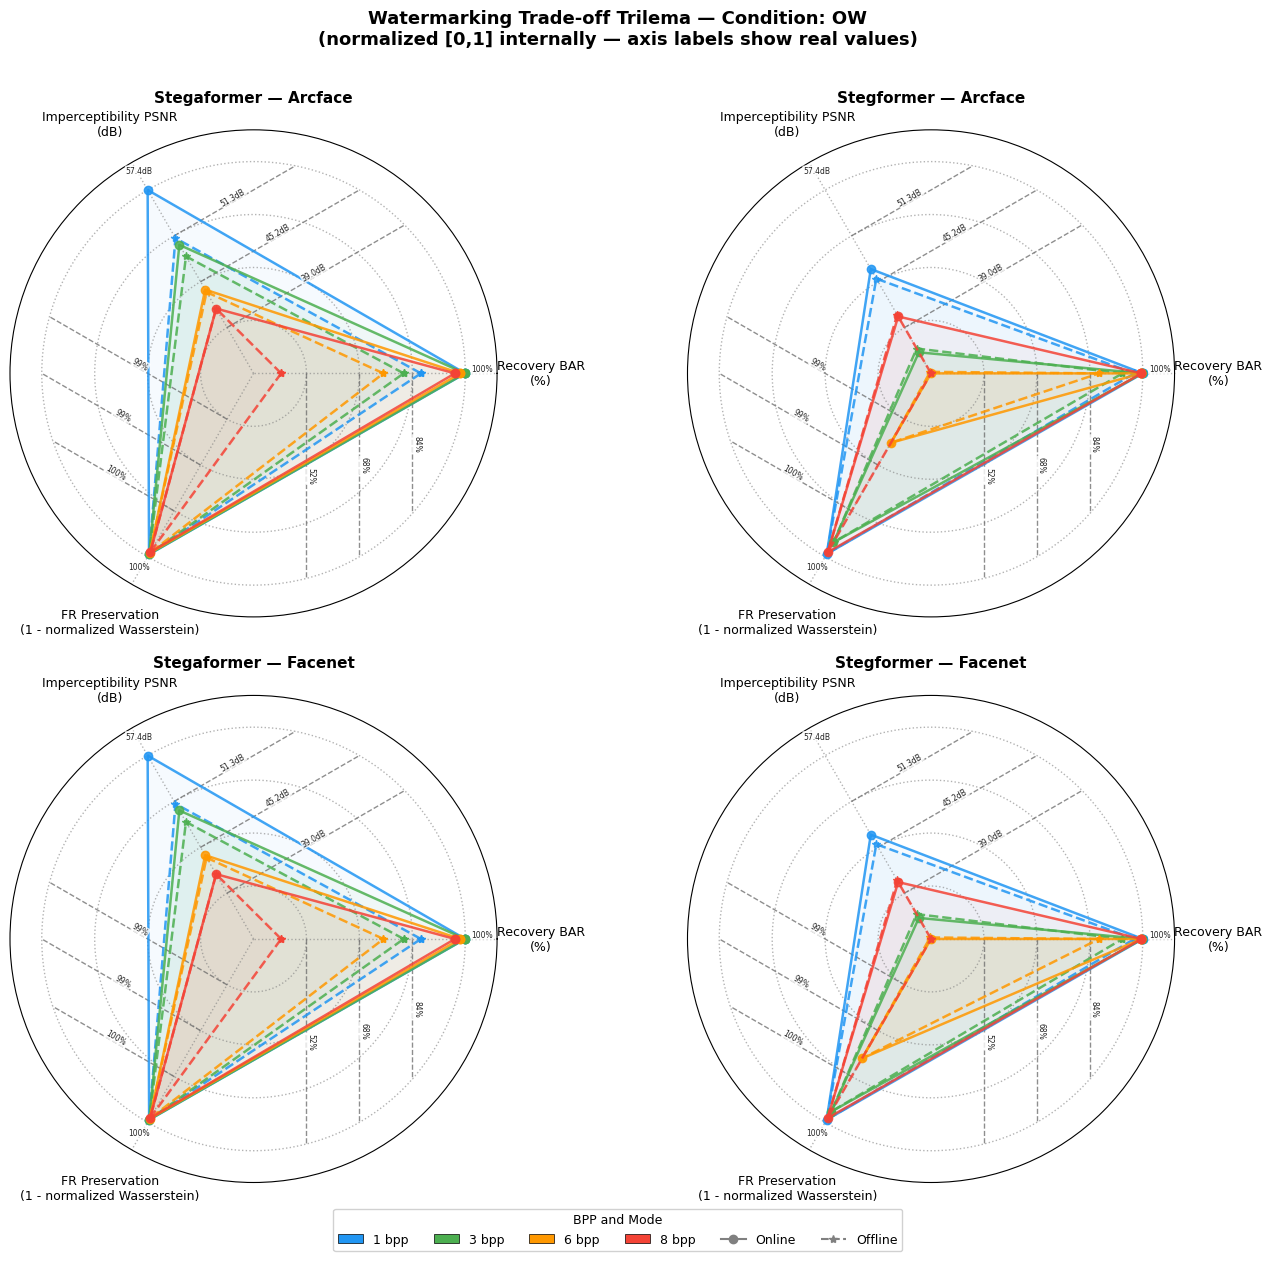

In [199]:
plot_spider(
    df_agg,
    dist_metric='ws_inv_norm',
    condition='OW',
    save_path='spider_trilema_WW_ws'
)

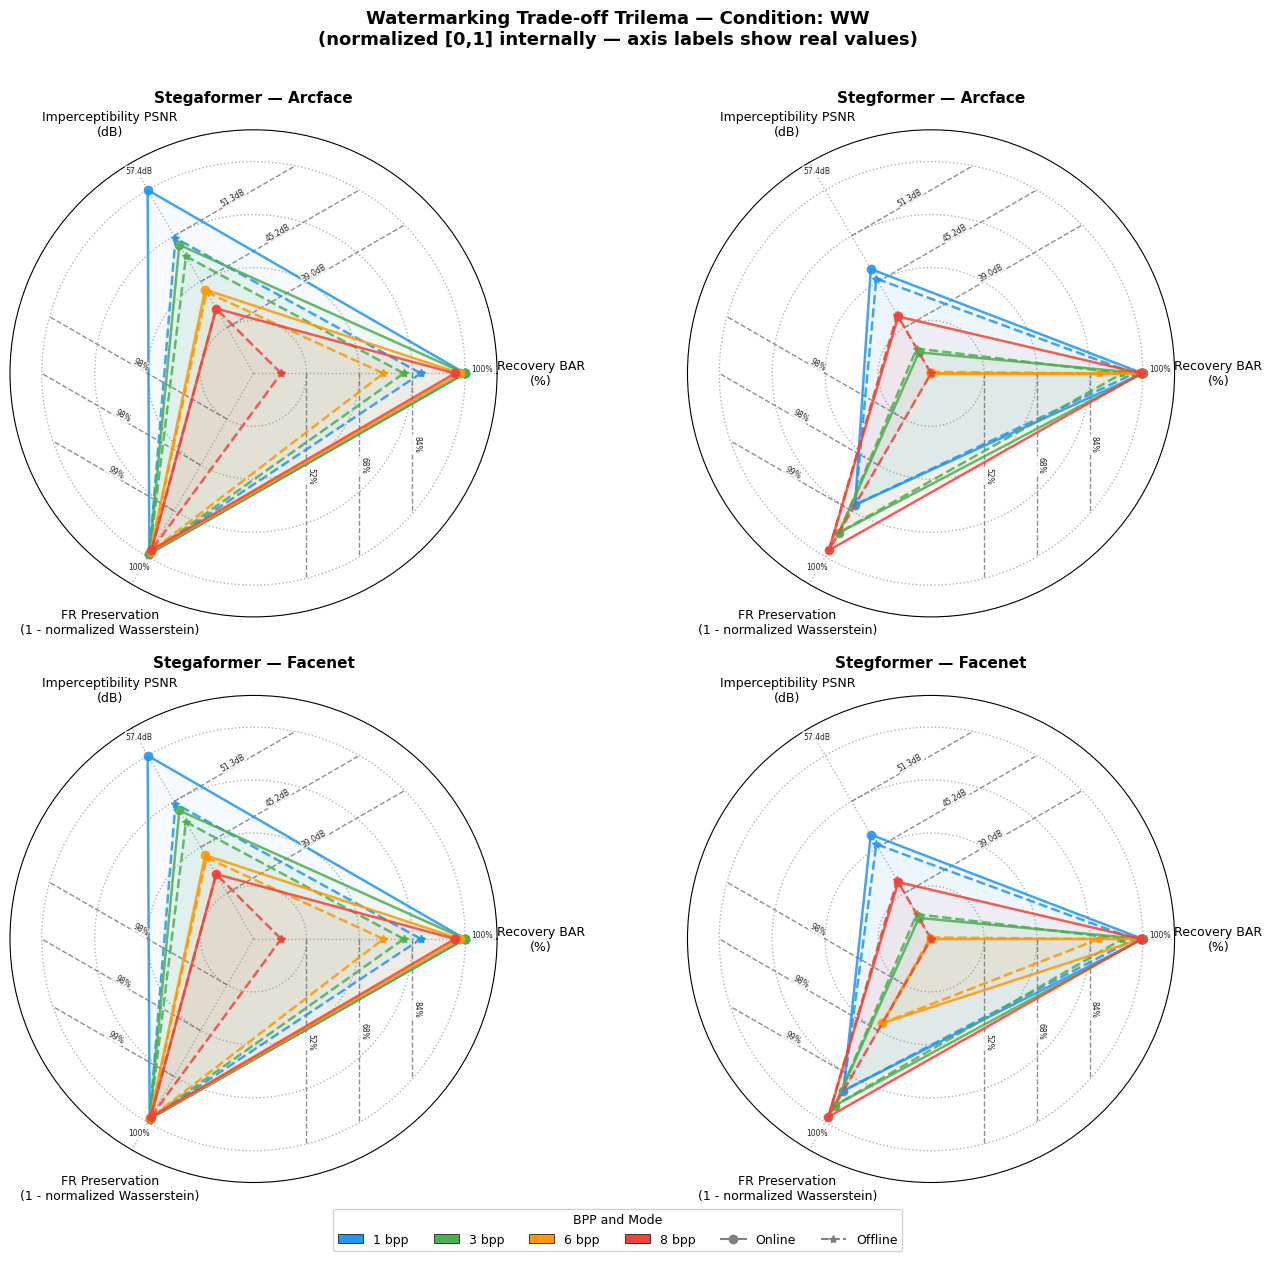

In [200]:
plot_spider(
    df_agg,
    dist_metric='ws_inv_norm',
    condition='WW',
    save_path='spider_trilema_WW_ws'
)

In [33]:
df_merged[(df_merged.bpp==6)&(df_merged.watermark=='stegformer')]

,watermark,train_dataset,test_dataset,bpp,accuracy,psnr,ssim,mode,recognizer,condition,kl_divergence,delta_mean,wasserstein,cohen_d,js_divergence
224,stegformer,celeba_hq,CFD,6,0.775926,31.593856,0.923243,offline,arcface,OW,0.076736,0.016697,0.016697,0.432701,0.026594
225,stegformer,celeba_hq,CFD,6,0.775926,31.593856,0.923243,offline,arcface,WW,0.116599,0.021667,0.021694,0.533657,0.042979
226,stegformer,celeba_hq,CFD,6,0.775926,31.593856,0.923243,offline,facenet,OW,0.060032,0.009391,0.009399,0.229370,0.018649
227,stegformer,celeba_hq,CFD,6,0.775926,31.593856,0.923243,offline,facenet,WW,0.043083,0.009319,0.009400,0.224588,0.017647
228,stegformer,celeba_hq,facelab_london,6,0.779977,35.177926,0.948864,offline,arcface,OW,1.443756,0.072928,0.072928,1.766328,0.353998
229,stegformer,celeba_hq,facelab_london,6,0.779977,35.177926,0.948864,offline,arcface,WW,0.725365,0.061995,0.061995,1.414951,0.244602
230,stegformer,celeba_hq,facelab_london,6,0.779977,35.177926,0.948864,offline,facenet,OW,0.541478,0.042176,0.042176,0.928924,0.180685
231,stegformer,celeba_hq,facelab_london,6,0.779977,35.177926,0.948864,offline,facenet,WW,0.362539,0.035256,0.035652,0.795131,0.132635
232,stegformer,celeba_hq,ONOT_set1,6,0.780602,31.460615,0.927854,offline,arcface,OW,0.031812,0.018761,0.019027,0.230968,0.011162
233,stegformer,celeba_hq,ONOT_set1,6,0.780602,31.460615,0.927854,offline,arcface,WW,0.033429,0.022299,0.022365,0.260746,0.012380


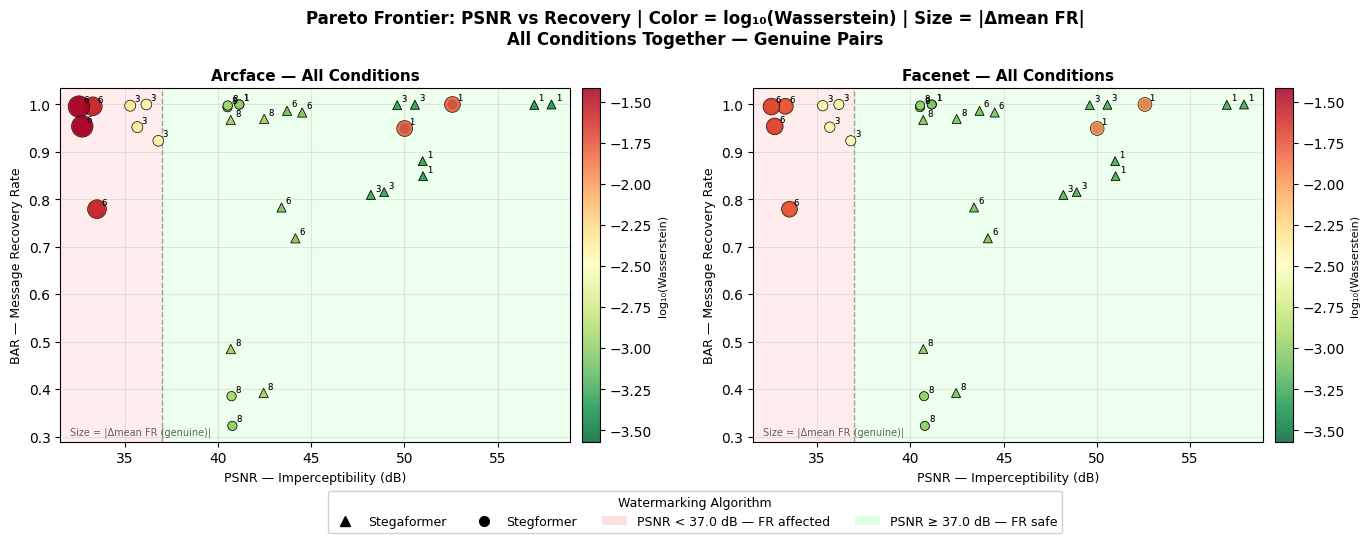

In [202]:
plot_pareto_2d(df_merged,
               fr_metric='wasserstein',
               condition='together',
               psnr_threshold=37.0,
               save_path='pareto_2d_WW_OW_together')

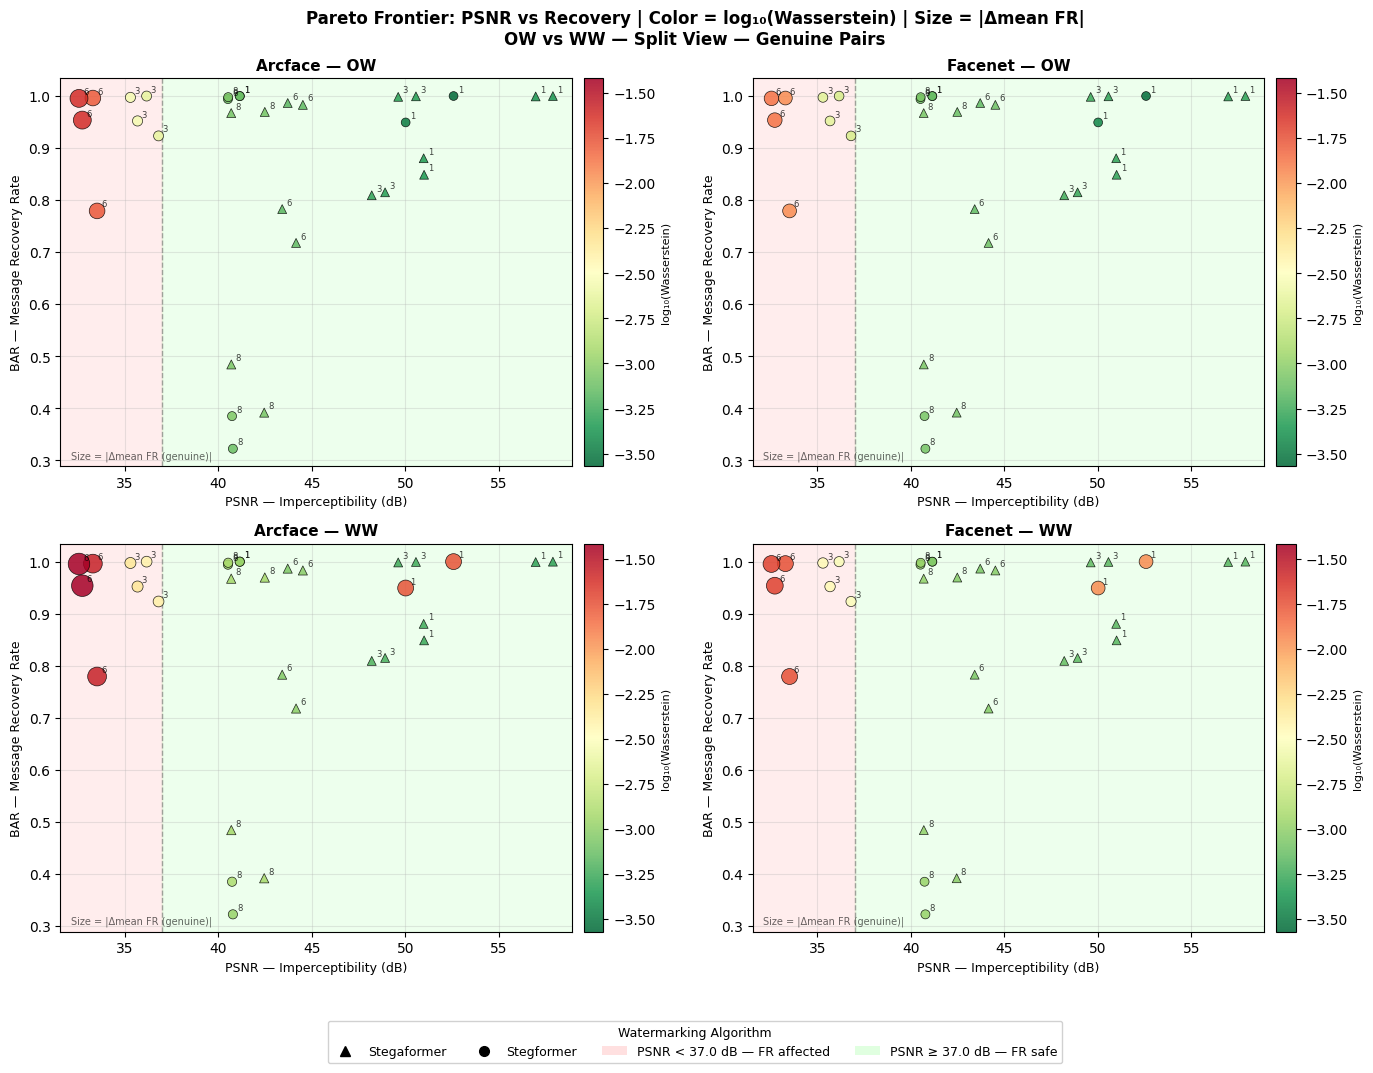

In [203]:
plot_pareto_2d(df_merged,
               fr_metric='wasserstein',
               condition='split',
               psnr_threshold=37.0,
              save_path='pareto_2d_WW_OW_split')

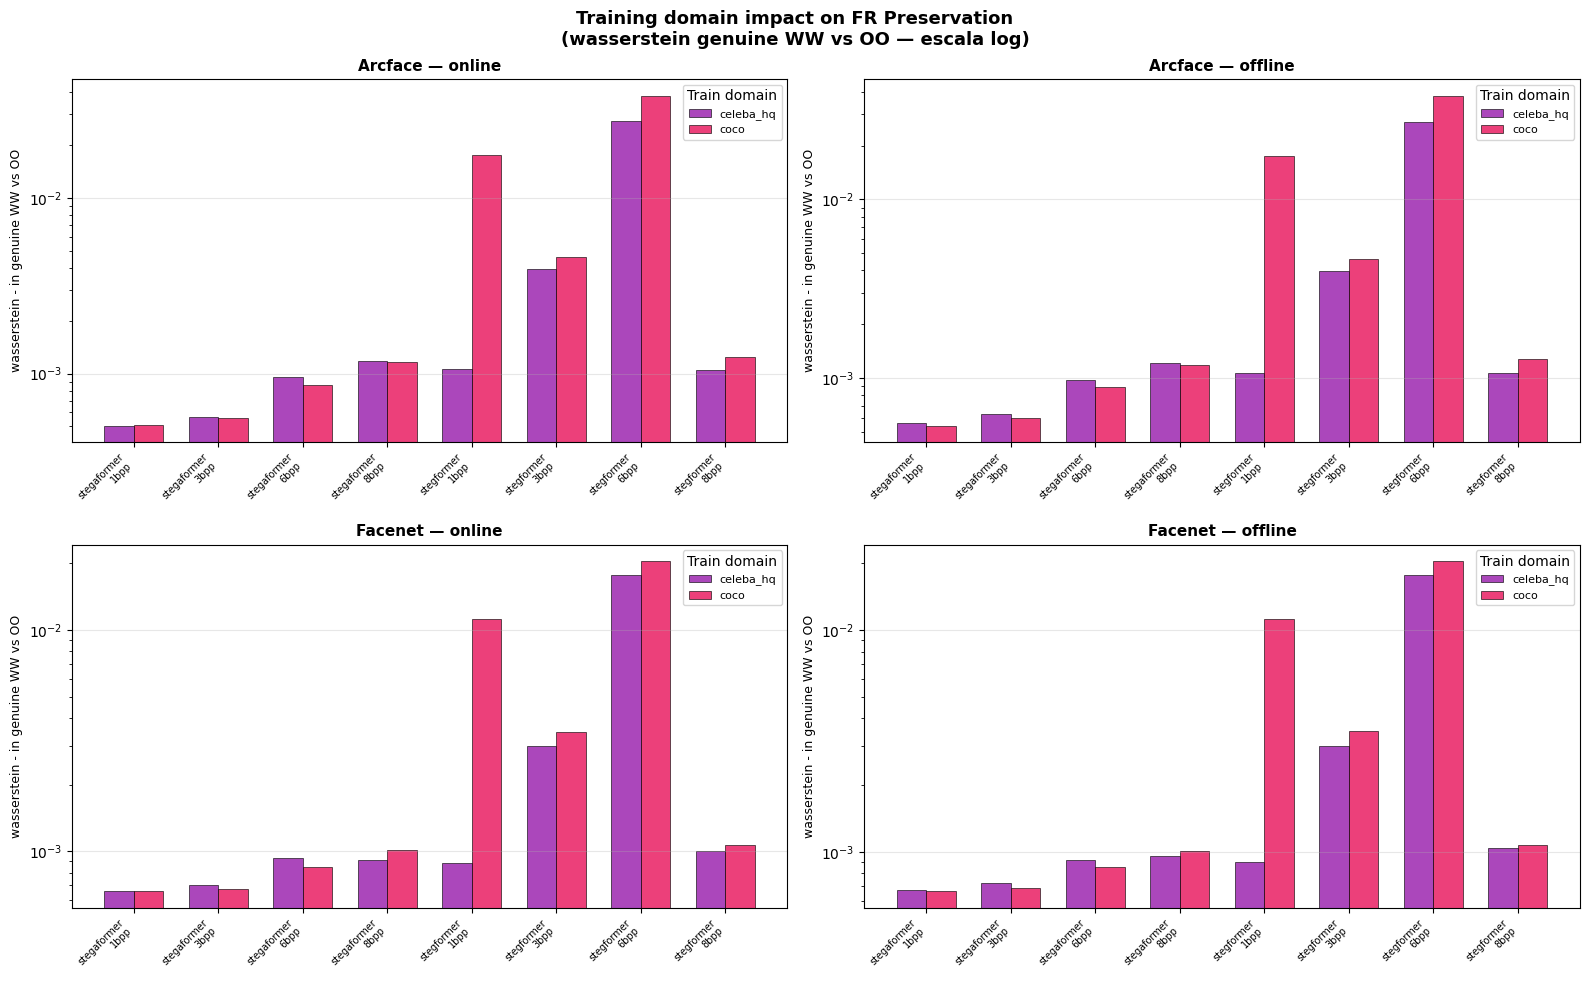

In [204]:
plot_fr_dist_by_train_domain(df_merged, 
                             fr_dist_metric='wasserstein', 
                             condition='WW', save_path='wasserstein_by_train_domain')

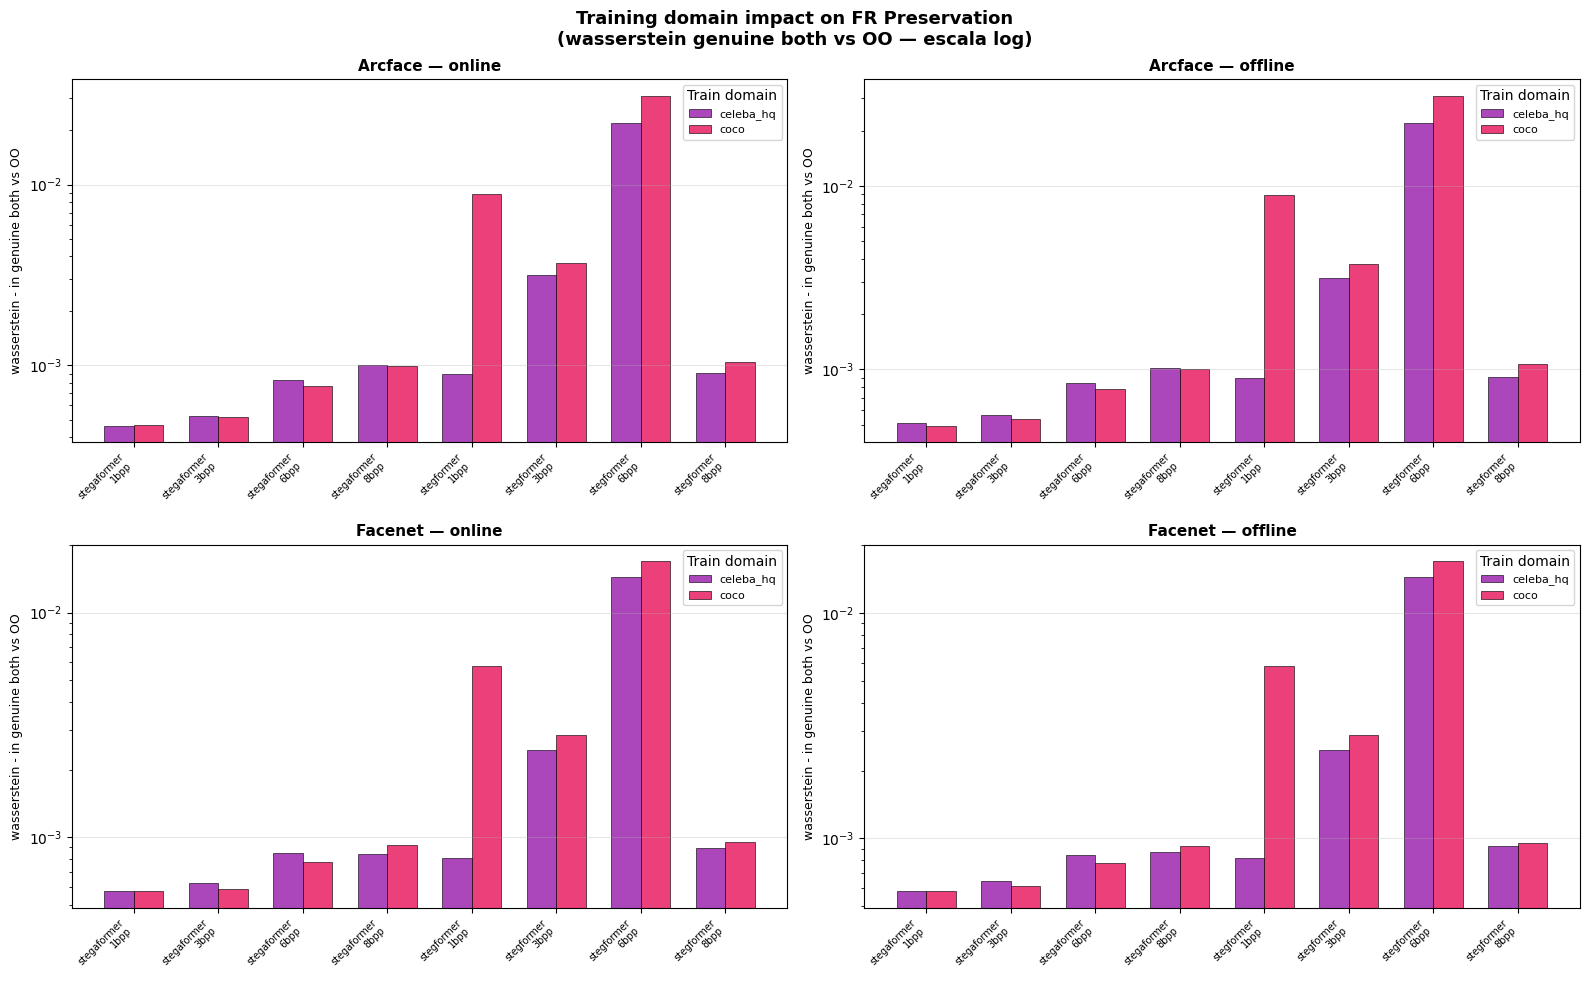

In [205]:
plot_fr_dist_by_train_domain(df_merged, 
                             fr_dist_metric='wasserstein', 
                             condition='both', save_path='wasserstein_by_train_domain')

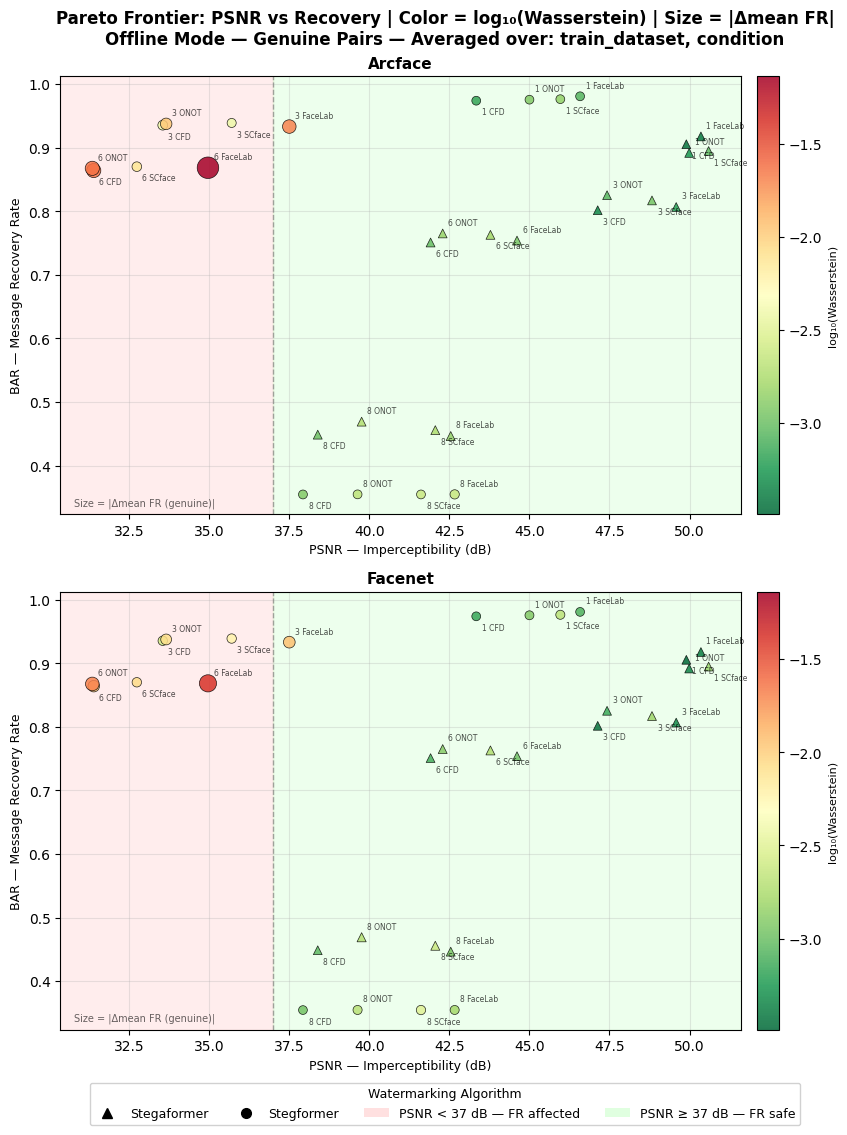

In [30]:
plot_pareto_2d_stacked(df_merged,
                        fr_metric='wasserstein',
                        average_by=['train_dataset', 'condition'],
                        psnr_threshold=37,
                        save_path='pareto_offline_avg')

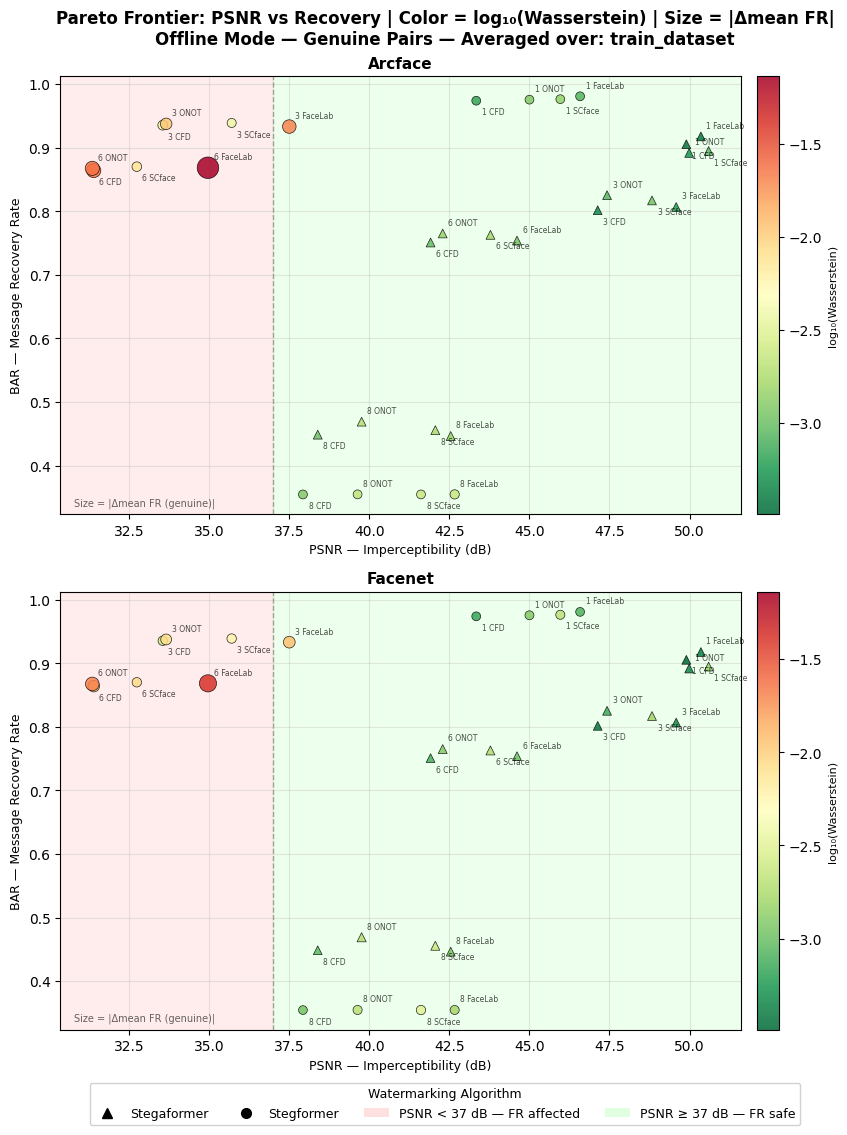

In [31]:
# Averaged over train_dataset only (OW and WW separate points):
plot_pareto_2d_stacked(df_merged,
                        fr_metric='wasserstein',
                        average_by=['train_dataset'],
                        psnr_threshold=37,
                        save_path='pareto_offline_avg_train')

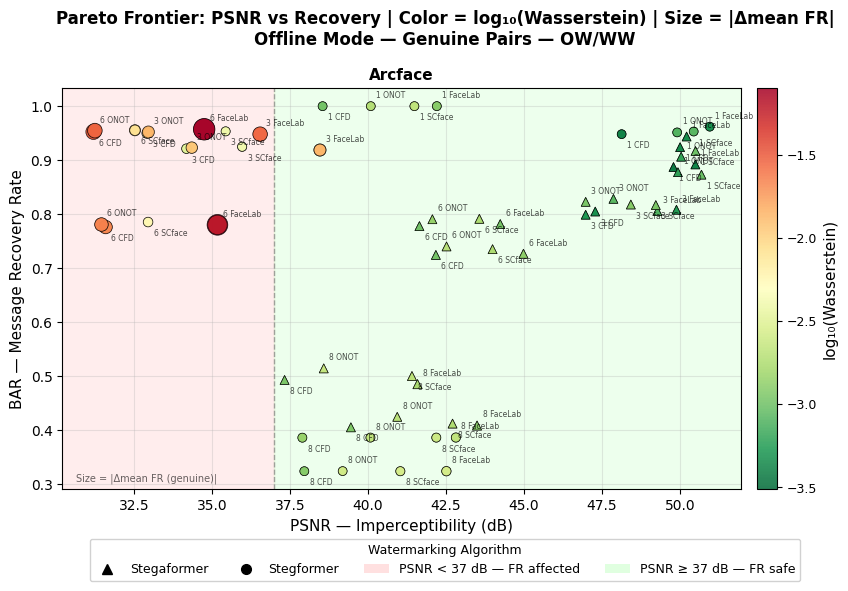

In [41]:
plot_pareto_2d_stacked(df_merged[df_merged['recognizer'] == 'arcface'],
                        fr_metric='wasserstein',
                        average_by=None,
                        psnr_threshold=37,
                        save_path='pareto_offline_all')

In [ ]:
df_merged, df_V = compute_V(df_merged)

# Ver el punto óptimo por recognizer
print(df_V.sort_values('V', ascending=False)
          .groupby('recognizer')
          .head(3)[['watermark','bpp','mode','recognizer','V','accuracy','psnr','kl_divergence']]
          .round(4))

plot_optimal_V(df_V)

In [ ]:



# ============================================================
# PLOT — PARETO 2D CON COLOR = TRAIN DOMAIN
# ============================================================

def plot_pareto_train_domain(df_merged, save_path='pareto_train_domain'):
    train_colors = {'coco': '#E91E63', 'celeba_hq': '#9C27B0'}
    wm_markers   = {'stegformer': 'o', 'stegaformer': '^'}
    mode_styles  = {'online': '', 'offline': '//'}  # hatch en edgecolor
    recognizers  = df_merged['recognizer'].unique()

    # Escalar KL a tamaño de punto globalmente
    abs_kl      = df_merged['kl_divergence']
    size_scaled = 40 + 250 * (abs_kl - abs_kl.min()) / (abs_kl.max() - abs_kl.min() + 1e-10)

    fig, axes = plt.subplots(1, len(recognizers), figsize=(14, 5))
    if len(recognizers) == 1:
        axes = [axes]

    for ax, rec in zip(axes, recognizers):
        sub = df_merged[df_merged['recognizer'] == rec].copy()
        sub['size'] = size_scaled[sub.index]

        for wm in sub['watermark'].unique():
            for train in sub['train_dataset'].unique():
                mask  = (sub['watermark'] == wm) & (sub['train_dataset'] == train)
                wsub  = sub[mask]
                if wsub.empty:
                    continue

                ax.scatter(
                    wsub['psnr'], wsub['accuracy'],
                    c=train_colors[train],
                    marker=wm_markers[wm],
                    s=wsub['size'],
                    alpha=0.8,
                    edgecolors='k', linewidths=0.4,
                    label=f'{wm} — {train}'
                )

                # Anotar bpp y mode
                for _, row in wsub.iterrows():
                    ax.annotate(
                        f"{int(row['bpp'])}{'o' if row['mode']=='offline' else ''}",
                        (row['psnr'], row['accuracy']),
                        fontsize=6, alpha=0.7,
                        xytext=(3, 3), textcoords='offset points'
                    )

        ax.set_xlabel('PSNR (imperceptibilidad)', fontsize=10)
        ax.set_ylabel('ACC (recuperación mensaje)', fontsize=10)
        ax.set_title(rec.capitalize(), fontsize=12, fontweight='bold')
        ax.legend(fontsize=7, ncol=2, title='▲=stegaformer  ●=stegformer')
        ax.grid(True, alpha=0.3)

        ax.text(0.02, 0.02,
                'Tamaño = KL divergence\n"o" = offline',
                transform=ax.transAxes, fontsize=7, alpha=0.6)

    fig.suptitle('Pareto: PSNR vs ACC | color=dominio entrenamiento | tamaño=KL',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{save_path}.pdf', bbox_inches='tight', dpi=300)
    plt.savefig(f'{save_path}.png', bbox_inches='tight', dpi=300)
    plt.show()


# ============================================================
# EJECUCIÓN
# ============================================================

plot_kl_by_train_domain(df_merged)
plot_pareto_train_domain(df_merged)

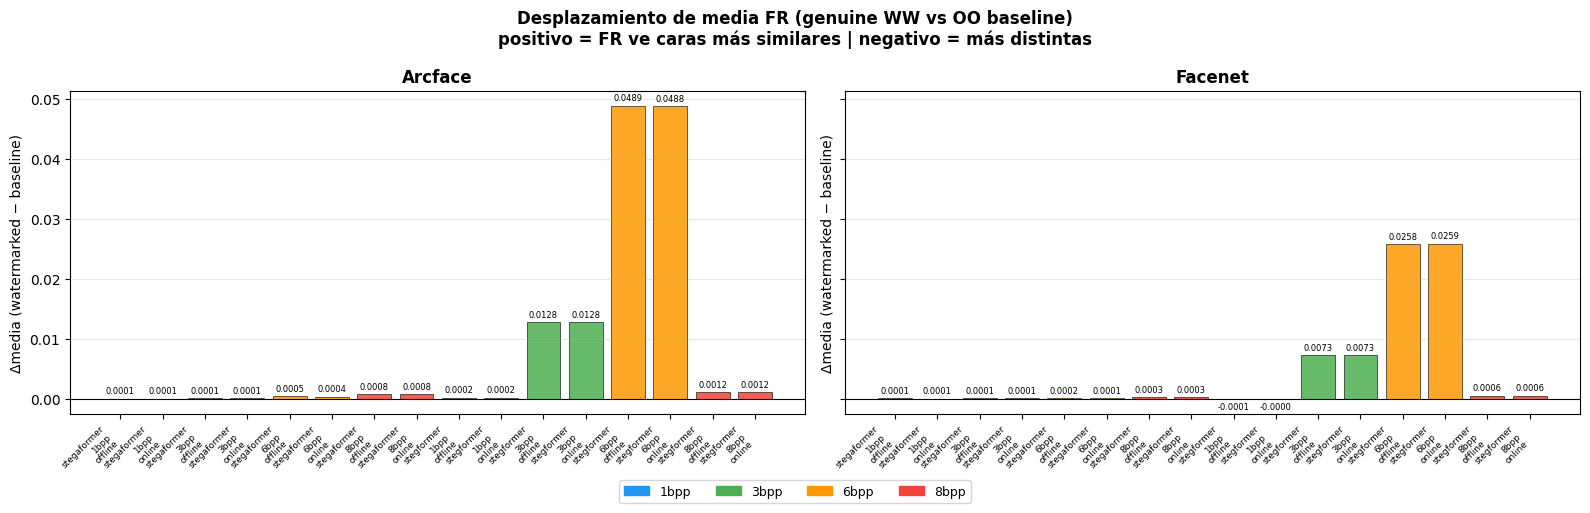

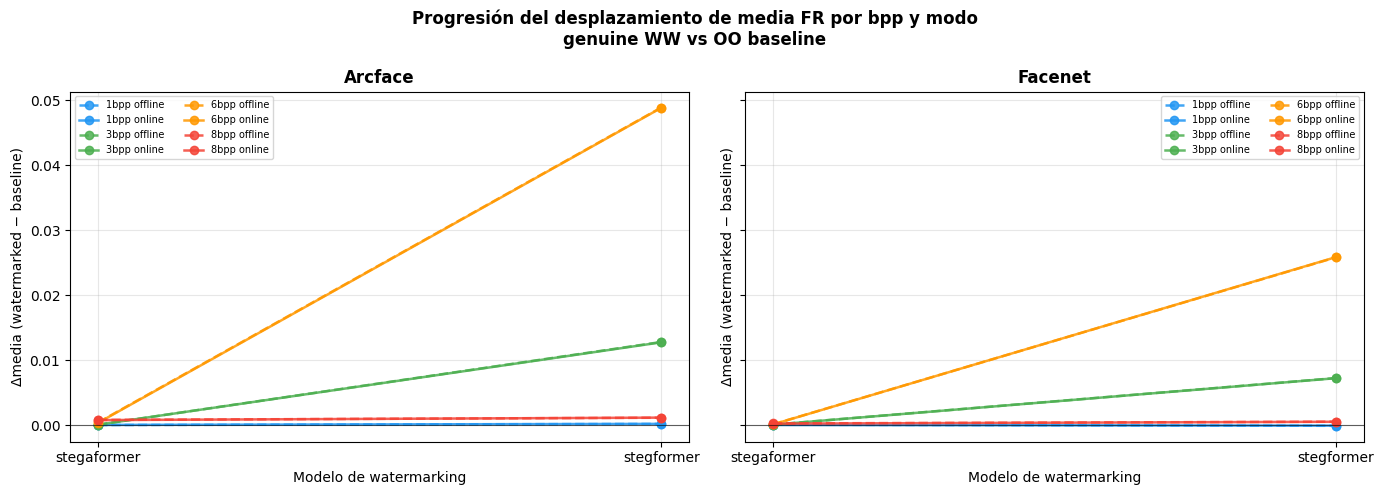

In [49]:
# ============================================================
# PLOT delta_mean — BARRAS SIGNED
# ============================================================

def plot_delta_mean_bars(df_V, save_path='delta_mean_bars'):
    recognizers = df_V['recognizer'].unique()
    fig, axes = plt.subplots(1, len(recognizers), figsize=(16, 5), sharey=True)
    if len(recognizers) == 1:
        axes = [axes]

    bpp_colors = {1: '#2196F3', 3: '#4CAF50', 6: '#FF9800', 8: '#F44336'}

    for ax, rec in zip(axes, recognizers):
        sub = df_V[df_V['recognizer'] == rec].copy()
        sub['label'] = sub['watermark'] + '\n' + sub['bpp'].astype(str) + 'bpp\n' + sub['mode']
        sub = sub.sort_values(['watermark', 'bpp', 'mode'])

        bars = ax.bar(
            range(len(sub)),
            sub['delta_mean'],
            color=[bpp_colors[b] for b in sub['bpp']],
            edgecolor='k', linewidth=0.5, alpha=0.85
        )

        ax.axhline(0, color='black', linewidth=0.8)

        for bar, v in zip(bars, sub['delta_mean']):
            offset = 0.0005 if v >= 0 else -0.0005
            va = 'bottom' if v >= 0 else 'top'
            ax.text(bar.get_x() + bar.get_width()/2,
                    v + offset, f'{v:.4f}',
                    ha='center', va=va, fontsize=6)

        ax.set_xticks(range(len(sub)))
        ax.set_xticklabels(sub['label'], fontsize=6.5, rotation=45, ha='right')
        ax.set_ylabel('Δmedia (watermarked − baseline)', fontsize=10)
        ax.set_title(rec.capitalize(), fontsize=12, fontweight='bold')
        ax.grid(True, axis='y', alpha=0.3)

    from matplotlib.patches import Patch
    legend_els = [Patch(color=c, label=f'{b}bpp') for b, c in bpp_colors.items()]
    fig.legend(handles=legend_els, loc='lower center', ncol=4,
               fontsize=9, bbox_to_anchor=(0.5, -0.02))

    fig.suptitle('Desplazamiento de media FR (genuine WW vs OO baseline)\n'
                 'positivo = FR ve caras más similares | negativo = más distintas',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{save_path}.pdf', bbox_inches='tight', dpi=300)
    plt.savefig(f'{save_path}.png', bbox_inches='tight', dpi=300)
    plt.show()


# ============================================================
# PLOT delta_mean — LÍNEAS POR BPP
# ============================================================

def plot_delta_mean_lines(df_V, save_path='delta_mean_lines'):
    recognizers = df_V['recognizer'].unique()
    fig, axes = plt.subplots(1, len(recognizers), figsize=(14, 5), sharey=True)
    if len(recognizers) == 1:
        axes = [axes]

    bpp_colors  = {1: '#2196F3', 3: '#4CAF50', 6: '#FF9800', 8: '#F44336'}
    mode_styles = {'online': '-', 'offline': '--'}

    for ax, rec in zip(axes, recognizers):
        sub = df_V[df_V['recognizer'] == rec].copy()

        for bpp in sorted(sub['bpp'].unique()):
            for mode in sub['mode'].unique():
                mask = (sub['bpp'] == bpp) & (sub['mode'] == mode)
                s = sub[mask].sort_values('watermark')
                ax.plot(
                    s['watermark'], s['delta_mean'],
                    color=bpp_colors[bpp],
                    linestyle=mode_styles[mode],
                    linewidth=1.8,
                    marker='o', markersize=6,
                    label=f'{bpp}bpp {mode}',
                    alpha=0.85
                )

        ax.axhline(0, color='black', linewidth=0.8, alpha=0.6)
        ax.set_xlabel('Modelo de watermarking', fontsize=10)
        ax.set_ylabel('Δmedia (watermarked − baseline)', fontsize=10)
        ax.set_title(rec.capitalize(), fontsize=12, fontweight='bold')
        ax.legend(fontsize=7, ncol=2)
        ax.grid(True, alpha=0.3)

    fig.suptitle('Progresión del desplazamiento de media FR por bpp y modo\n'
                 'genuine WW vs OO baseline',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{save_path}.pdf', bbox_inches='tight', dpi=300)
    plt.savefig(f'{save_path}.png', bbox_inches='tight', dpi=300)
    plt.show()


# ============================================================
# EJECUCIÓN
# ============================================================

plot_delta_mean_bars(df_V)
plot_delta_mean_lines(df_V)